<a href="https://colab.research.google.com/github/iweam/genai-bootcamp/blob/main/W2S4_Lab_RAG_Chatbot_Space.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:linear-gradient(135deg,#16304A 0%,#003C9C 100%);border-radius:14px;padding:22px 26px;color:#fff;font-family:Segoe UI,Arial,sans-serif;">
  <div style="display:flex;justify-content:space-between;align-items:center;gap:16px;">
    <div>
      <div style="font-size:13px;letter-spacing:1px;opacity:.85;text-transform:uppercase;">Generative AI Summer Bootcamp &middot; Najran University</div>
      <div style="font-size:26px;font-weight:800;margin-top:4px;">Lab — Build & Deploy a RAG Chatbot</div>
      <div style="font-size:15px;opacity:.92;margin-top:4px;">Week 2 · Session 4 — RAG II + Integration & Deployment</div>
    </div>
    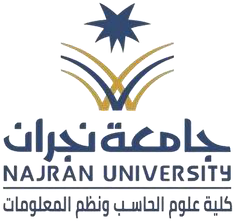
  </div>
  <div style="margin-top:16px;display:flex;gap:10px;flex-wrap:wrap;font-size:13px;">
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">🏆 NCA-GENL track</span>
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">⏱️ Lab: ≈ 45 minutes</span>
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">▶️ Runs on Google Colab (free)</span>
  </div>
</div>

<a target="_blank" href="https://colab.research.google.com/"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:16px 20px;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:16px;margin-bottom:6px;">🎓 Learning objectives</div>
<ul style="margin:0;padding-left:20px;font-size:15px;color:#16304A;"><li style="margin:5px 0;">Build a retriever with <b>MiniLM + FAISS</b> over your own documents.</li>
<li style="margin:5px 0;">Combine it with <b>Qwen2.5-1.5B-Instruct</b> into one end-to-end <b>RAG</b> function.</li>
<li style="margin:5px 0;">Ground every answer in retrieved context and <b>show its sources</b>.</li>
<li style="margin:5px 0;">Wrap the app in <b>Gradio</b> and launch a public demo from Colab.</li>
<li style="margin:5px 0;">Deploy the same app to a <b>Hugging Face Space</b> (app.py + requirements.txt).</li></ul></div>

## How to use this notebook

Run the cells **in order**, top to bottom (`Shift+Enter`). This lab assembles the retriever from Session 3 and the generator from Session 1 into a complete, deployable RAG chatbot. The short notes before each part tie the code back to today's slides.

<div style="border:1px solid #16304A33;border-left:6px solid #16304A;background:#EDF1F6;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#16304A;font-size:15px;margin-bottom:4px;">🔧 First: turn on the free GPU</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Click <b>Runtime → Change runtime type → T4 GPU → Save</b>. The retriever runs fine on CPU, but the Qwen generator is much faster on the T4.</div></div>

### Setup
We install four small, open libraries. None of them need a login or token.

In [1]:
# One-time setup (~1 minute)
!pip -q install -U "transformers>=4.44" "sentence-transformers>=3.0" faiss-cpu "gradio>=4.44" accelerate
print("Setup complete — now run the cells below in order.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.0/31.0 MB 16.0 MB/s eta 0:00:00
Setup complete — now run the cells below in order.


<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:15px;margin-bottom:4px;">ℹ️ What each library does</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;"><b>sentence-transformers</b> = the MiniLM embedder · <b>faiss-cpu</b> = the vector index · <b>transformers</b> = the Qwen generator · <b>gradio</b> = the web UI. All are open and ungated.</div></div>

## Part 1 — A tiny knowledge base

RAG answers questions about *your* documents. To keep the lab self-contained we use a small in-memory knowledge base. In a real project these chunks would come from your PDFs, web pages or wiki.

In [2]:
# Our "documents", already split into short chunks.
# (In Session 3 you produced chunks like these from real files.)
DOCS = [
    "The Generative AI Summer Bootcamp at Najran University runs for three weeks.",
    "Week 1 covers the foundations of generative AI and prompt engineering.",
    "Week 2 focuses on large language models, embeddings, and retrieval-augmented generation.",
    "Week 3 covers multimodal AI: vision, audio, and image generation.",
    "The bootcamp prepares students for the NVIDIA NCA-GENL and NCA-GENM associate exams.",
    "The NCA-GENL exam has 50 to 60 questions and a time limit of one hour.",
    "Students need a free Google Colab account and a free Hugging Face account.",
    "The refund policy: tuition is fully refundable up to seven days before the start date.",
    "All lab notebooks run on a free Colab T4 GPU with about 15 GB of memory.",
    "Certificates are issued to students who complete every hands-on lab.",
]
print(f"Knowledge base: {len(DOCS)} chunks")

Knowledge base: 10 chunks


## Part 2 — The retriever (MiniLM + FAISS)

We embed every chunk once, then build a FAISS index for fast similarity search. We normalise the vectors so an inner-product search behaves like **cosine similarity**.

In [3]:
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
doc_emb = embedder.encode(DOCS, normalize_embeddings=True)
doc_emb = np.asarray(doc_emb, dtype="float32")

index = faiss.IndexFlatIP(doc_emb.shape[1])   # inner product = cosine on normalised vectors
index.add(doc_emb)
print("Indexed", index.ntotal, "chunks; embedding dim =", doc_emb.shape[1])

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Indexed 10 chunks; embedding dim = 384


In [4]:
def retrieve(query, k=3):
    """Return the top-k (chunk_text, similarity_score) for a query."""
    q = embedder.encode([query], normalize_embeddings=True)
    q = np.asarray(q, dtype="float32")
    scores, idxs = index.search(q, k)
    return [(DOCS[i], float(s)) for i, s in zip(idxs[0], scores[0])]

# Quick check
for text, score in retrieve("How many questions are on the GENL exam?"):
    print(f"{score:.3f}  {text}")

0.786  The NCA-GENL exam has 50 to 60 questions and a time limit of one hour.
0.381  The bootcamp prepares students for the NVIDIA NCA-GENL and NCA-GENM associate exams.
0.283  Certificates are issued to students who complete every hands-on lab.


:<div style="border:1px solid #24783033;border-left:6px solid #247830;background:#E9F5EC;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#247830;font-size:15px;margin-bottom:4px;">💡 Tuning k</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;"><b>k</b> is the number of chunks you retrieve. Too few risks missing the answer; too many adds noise and burns context tokens. Start with <b>k = 3</b> and adjust.</div></div>

## Part 3 — The generator (Qwen2.5-1.5B-Instruct)

Now load the small open LLM. At fp16 it fits comfortably on the free T4 (~3 GB).

In [5]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

GEN_ID = "Qwen/Qwen2.5-1.5B-Instruct"   # open & ungated — no token needed
tokenizer = AutoTokenizer.from_pretrained(GEN_ID)
model = AutoModelForCausalLM.from_pretrained(
    GEN_ID, torch_dtype=torch.float16, device_map="auto"
)
print("Generator loaded on:", next(model.parameters()).device)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Generator loaded on: cuda:0


In [6]:
def generate(prompt, max_new_tokens=256):
    """Send a single prompt through the instruct model and return the reply text."""
    messages = [{"role": "user", "content": prompt}]
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt"
    ).to(model.device)
    out = model.generate(
        input_ids=inputs['input_ids'],
        attention_mask=inputs['attention_mask'],
        max_new_tokens=max_new_tokens,
        do_sample=False,                     # temperature 0 -> factual & repeatable
        pad_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()

print(generate("Say hello in one short sentence."))

Hello! How can I assist you today?


## Part 4 — Put it together: the grounded RAG function

This is the heart of the lab. We **retrieve**, build a **grounded prompt** (the template from the slides), **generate**, and return the answer **with its sources**. The prompt tells the model to use *only* the context and to say *"I don't know"* otherwise — our main guardrail against hallucination.

In [7]:
def build_prompt(question, chunks):
    context = "\n".join(f"[{i+1}] {text}" for i, (text, _) in enumerate(chunks))
    return (
        "You are a helpful assistant for the Najran University AI Bootcamp.\n"
        "Answer the question using ONLY the context below.\n"
        "If the answer is not in the context, say exactly: I don't know.\n"
        "Cite the sources you use like [1], [2].\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {question}\n\n"
        "Answer:"
    )

def rag_answer(question, k=3, min_score=0.15):
    chunks = retrieve(question, k=k)
    # Guardrail: if nothing is relevant, refuse instead of guessing.
    if not chunks or chunks[0][1] < min_score:
        return "I don't know. (No relevant context was found.)", []
    prompt = build_prompt(question, chunks)
    answer = generate(prompt)
    sources = [text for text, _ in chunks]
    return answer, sources

In [8]:
# Try it
answer, sources = rag_answer("How many questions are on the NCA-GENL exam?")
print("ANSWER:\n", answer)
print("\nSOURCES:")
for i, s in enumerate(sources, 1):
    print(f"  [{i}] {s}")

ANSWER:
 The NCA-GENL exam has 50 to 60 questions. [1]

SOURCES:
  [1] The NCA-GENL exam has 50 to 60 questions and a time limit of one hour.
  [2] The bootcamp prepares students for the NVIDIA NCA-GENL and NCA-GENM associate exams.
  [3] Certificates are issued to students who complete every hands-on lab.


In [9]:
# Guardrail in action: ask something the documents do not cover
answer, sources = rag_answer("What is the capital of France?")
print("ANSWER:", answer)
print("SOURCES:", sources)

ANSWER: I don't know. (No relevant context was found.)
SOURCES: []


<div style="border:1px solid #0C607833;border-left:6px solid #0C6078;background:#E4F1F0;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#0C6078;font-size:15px;margin-bottom:4px;">🎯 Exam tip — NCA-GENL</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">RAG and deployment sit in the <b>Software Development</b> and <b>Experimentation</b> domains. Remember the two halves to evaluate: <b>retrieval quality</b> (context recall/precision) and <b>generation quality</b> (faithfulness — is the answer supported by the context?).</div></div>

<div style="border:1px solid #6B3FA033;border-left:6px solid #6B3FA0;background:#F1ECF8;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#6B3FA0;font-size:15px;margin-bottom:4px;">✍️ Your turn</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Add your own facts to the knowledge base and ask about them. Then make the answer harder to ground — does the model correctly say "I don't know"?</div></div>

In [10]:
# 1) Add a new chunk, then RE-RUN the Part 2 indexing cell so it is embedded.
DOCS.append("The bootcamp instructor email is ynalrubyli@nu.edu.sa")
print("Now re-run the Part 2 cell to re-index, then ask:")

# 2) After re-indexing, try your own question here:
answer, sources = rag_answer("What is the instructor email?")
print(answer); print(sources)

Now re-run the Part 2 cell to re-index, then ask:
I don't know.
['Students need a free Google Colab account and a free Hugging Face account.', 'The Generative AI Summer Bootcamp at Najran University runs for three weeks.', 'Certificates are issued to students who complete every hands-on lab.']


## Part 5 — Wrap it in a Gradio interface

A few lines of Gradio turn `rag_answer` into a web UI. We show the answer **and** the sources in two output boxes, then launch a public demo with `share=True` — a link you can open on your phone.

In [11]:
import gradio as gr

def chat_fn(question):
    answer, sources = rag_answer(question)
    sources_md = "\n".join(f"{i}. {s}" for i, s in enumerate(sources, 1)) or "(none)"
    return answer, sources_md

demo = gr.Interface(
    fn=chat_fn,
    inputs=gr.Textbox(label="Ask about the bootcamp", placeholder="e.g. What does Week 2 cover?"),
    outputs=[gr.Textbox(label="Answer"), gr.Textbox(label="Sources")],
    title="Najran Bootcamp RAG Chatbot",
    description="Grounded answers from the bootcamp knowledge base (MiniLM + FAISS + Qwen2.5).",
    examples=["What does Week 2 cover?", "How many questions are on the NCA-GENL exam?"],
)
demo.launch(share=True)   # share=True gives a public link from inside Colab

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://89a765ce35946e52ed.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


<div style="border:1px solid #C2670D33;border-left:6px solid #C2670D;background:#FCEFE0;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#C2670D;font-size:15px;margin-bottom:4px;">⚠️ About the share link</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">The <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">share=True</code> link is a <b>temporary</b> tunnel that lives only while this cell runs (about 72 hours, or until you stop the cell). For a permanent URL, deploy to a Hugging Face Space — that's Part 6.</div></div>

## Part 6 — Deploy to a Hugging Face Space

Now we make the app permanent and public. A **Space** is just a Git repo that Hugging Face builds and runs for you. You only need **two files**: `app.py` and `requirements.txt`. You already have a Hugging Face account from the Week-1 setup lab.

### 🔧 Step A — Create the Space</div>
1) Go to <b>huggingface.co/new-space</b>.  
2) Owner = your username · Space name = <b>genai-bootcamp-rag</b>.  
3) SDK = <b>Gradio</b> · Hardware = <b>CPU basic (free)</b> · Visibility = Public.  
4) Click <b>Create Space</b>.</div></div>

### Step B — Generate `app.py`
Run the cell below to write `app.py` to this Colab session. It is the same RAG logic as above, packaged as a standalone script. (On the free CPU Space we load Qwen on CPU — small but it works.)

In [12]:
app_code = r'''import numpy as np
import faiss, torch, gradio as gr
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM

DOCS = [
    "The Generative AI Summer Bootcamp at Najran University runs for three weeks.",
    "Week 1 covers the foundations of generative AI and prompt engineering.",
    "Week 2 focuses on large language models, embeddings, and retrieval-augmented generation.",
    "Week 3 covers multimodal AI: vision, audio, and image generation.",
    "The bootcamp prepares students for the NVIDIA NCA-GENL and NCA-GENM associate exams.",
    "The NCA-GENL exam has 50 to 60 questions and a time limit of one hour.",
    "Students need a free Google Colab account and a free Hugging Face account.",
    "The refund policy: tuition is fully refundable up to seven days before the start date.",
    "All lab notebooks run on a free Colab T4 GPU with about 15 GB of memory.",
    "Certificates are issued to students who complete every hands-on lab.",
]

embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
emb = np.asarray(embedder.encode(DOCS, normalize_embeddings=True), dtype="float32")
index = faiss.IndexFlatIP(emb.shape[1]); index.add(emb)

GEN_ID = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(GEN_ID)
model = AutoModelForCausalLM.from_pretrained(GEN_ID, torch_dtype=torch.float32)

def retrieve(query, k=3):
    q = np.asarray(embedder.encode([query], normalize_embeddings=True), dtype="float32")
    scores, idxs = index.search(q, k)
    return [(DOCS[i], float(s)) for i, s in zip(idxs[0], scores[0])]

def generate(prompt, max_new_tokens=256):
    msgs = [{"role": "user", "content": prompt}]

    inputs = tokenizer.apply_chat_template(
        msgs,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True
    )

    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )

    return tokenizer.decode(
        out[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).strip()

def rag_answer(question, k=3, min_score=0.15):
    chunks = retrieve(question, k=k)
    if not chunks or chunks[0][1] < min_score:
        return "I dont know. (No relevant context was found.)", []
    ctx = "\n".join(f"[{i+1}] {t}" for i, (t, _) in enumerate(chunks))
    prompt = ("Answer using ONLY the context below. If the answer is not in the context, "
              "say: I dont know. Cite sources like [1], [2].\n\n"
              f"Context:\n{ctx}\n\nQuestion: {question}\n\nAnswer:")
    return generate(prompt), [t for t, _ in chunks]

def chat_fn(question):
    answer, sources = rag_answer(question)
    srcs = "\n".join(f"{i}. {s}" for i, s in enumerate(sources, 1)) or "(none)"
    return answer, srcs

demo = gr.Interface(
    fn=chat_fn,
    inputs=gr.Textbox(label="Ask about the bootcamp"),
    outputs=[gr.Textbox(label="Answer"), gr.Textbox(label="Sources")],
    title="Najran Bootcamp RAG Chatbot",
)

if __name__ == "__main__":
    demo.launch()
'''
with open("app.py", "w") as f:
    f.write(app_code)
print("Wrote app.py (", len(app_code), "chars )")

Wrote app.py ( 3121 chars )


### Step C — Generate `requirements.txt`
These are the libraries the Space installs on build. `faiss-cpu` and CPU-only Torch are used because the free Space has no GPU.

In [13]:
requirements = """\
transformers>=4.44
sentence-transformers>=3.0
faiss-cpu
torch
gradio>=4.44
accelerate
"""
with open("requirements.txt", "w") as f:
    f.write(requirements)
print(requirements)

transformers>=4.44
sentence-transformers>=3.0
faiss-cpu
torch
gradio>=4.44
accelerate



<div style="border:1px solid #16304A33;border-left:6px solid #16304A;background:#EDF1F6;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#16304A;font-size:15px;margin-bottom:4px;">🔧 Step D — Upload the two files</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;"><b>Easiest (web):</b> open your Space → <b>Files</b> tab → <b>Add file → Upload files</b> → drag in <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">app.py</code> and <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">requirements.txt</code> (download them from Colab's file panel on the left) → <b>Commit</b>. The Space rebuilds automatically and goes live in a few minutes at <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">huggingface.co/spaces/<your-username>/genai-bootcamp-rag</code>.</div></div>

### Step E (optional) — Push from code with the Hub API
Prefer the terminal-free route? You can upload straight from this notebook using a **write** token from your account.

<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:15px;margin-bottom:4px;">ℹ️ Optional — needs a free write token</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Create a token at <b>huggingface.co/settings/tokens</b> (role: <b>Write</b>), then add it in Colab via the 🔑 sidebar as a secret named <b>HF_TOKEN</b>. Skip this if you uploaded via the web in Step D.</div></div>

In [ ]:
# OPTIONAL — programmatic upload. Safe to skip if you used the web UI.
from huggingface_hub import HfApi, create_repo
from google.colab import userdata

HF_USERNAME = "iweam"  # <-- change to your HF username
REPO = f"{HF_USERNAME}/genai-bootcamp-rag"
token = userdata.get("HF_TOKEN")

create_repo(REPO, repo_type="space", space_sdk="gradio", exist_ok=True, token=token)
api = HfApi(token=token)
for fname in ["app.py", "requirements.txt"]:
    api.upload_file(path_or_fileobj=fname, path_in_repo=fname,
                    repo_id=REPO, repo_type="space")
print(f"Pushed to https://huggingface.co/spaces/{REPO}")

<div style="border:1px solid #24783033;border-left:6px solid #247830;background:#E9F5EC;border-radius:10px;padding:16px 20px;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#247830;font-size:16px;margin-bottom:6px;">✅ Recap &amp; exam-readiness check</div>
<ul style="margin:0;padding-left:20px;font-size:15px;"><li style="margin:5px 0;">RAG = <b>retrieve → augment → generate</b>; the LLM only sees the question + retrieved chunks.</li>
<li style="margin:5px 0;">A <b>grounding prompt</b> ("use ONLY the context… else say I don't know") is the core anti-hallucination guardrail.</li>
<li style="margin:5px 0;">Always return the <b>sources</b> so answers are verifiable.</li>
<li style="margin:5px 0;">Evaluate both halves: <b>retrieval</b> (context recall/precision) and <b>generation</b> (faithfulness, relevance).</li>
<li style="margin:5px 0;"><b>Gradio</b> wraps a function into a UI; <code>demo.launch(share=True)</code> gives a temporary public link.</li>
<li style="margin:5px 0;">A <b>Hugging Face Space</b> needs just <code>app.py</code> + <code>requirements.txt</code>; every push auto-rebuilds.</li></ul></div>